A store claims that the distribution of customer purchases across product categories is uniform (equal proportion).
A data scientist suspects that some categories sell more than others.

We want to test whether observed sales match expected proportions using the Chi-Square Goodness-of-Fit test.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)  # reproducibility

categories = ["Electronics", "Clothing", "Groceries", "Books"]
n_customers = 200

# Suppose real sales have different proportions
# Electronics: 40%, Clothing: 30%, Groceries: 20%, Books: 10%
true_probs = [0.4, 0.3, 0.2, 0.1]

# Generate observed sales data
observed_sales = np.random.multinomial(n_customers, true_probs)

df = pd.DataFrame({
    "Category": categories,
    "Observed": observed_sales
})

print(df)


      Category  Observed
0  Electronics        77
1     Clothing        64
2    Groceries        45
3        Books        14


𝐻
0
H
0
	​

: Observed sales follow the expected proportions (distribution is uniform or as claimed).

𝐻
𝑎
H
a
	​

: Observed sales do not follow the expected proportions.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)  # reproducibility

categories = ["Electronics", "Clothing", "Groceries", "Books"]
n_customers = 200

# Suppose real sales have different proportions
# Electronics: 40%, Clothing: 30%, Groceries: 20%, Books: 10%
true_probs = [0.4, 0.3, 0.2, 0.1]

# Generate observed sales data
observed_sales = np.random.multinomial(n_customers, true_probs)

df = pd.DataFrame({
    "Category": categories,
    "Observed": observed_sales
})

print(df)


      Category  Observed
0  Electronics        77
1     Clothing        64
2    Groceries        45
3        Books        14


In [6]:
from scipy.stats import chisquare

# Suppose store claims uniform distribution (equal probability)
expected_probs = [0.25, 0.25, 0.25, 0.25]  
expected_counts = np.array(expected_probs) * n_customers

chi_stat, p_value = chisquare(df["Observed"], f_exp=expected_counts)

print("\n--- Chi-Square Test Results ---")
print("Chi-Square Statistic:", round(chi_stat, 3))
print("p-value:", round(p_value, 4))



--- Chi-Square Test Results ---
Chi-Square Statistic: 44.92
p-value: 0.0


In [7]:
from scipy.stats import chisquare, chi2

alpha = 0.05
k = len(categories)
dfree = k - 1  # degrees of freedom

# Chi-square test
chi_stat, p_value = chisquare(df["Observed"], f_exp=expected_counts)

# Critical value
chi_crit = chi2.ppf(1 - alpha, dfree)

print("\n--- Chi-Square Test Results ---")
print("Chi-Square Statistic:", round(chi_stat, 3))
print(f"Chi-Square Critical Value (α={alpha}):", round(chi_crit, 3))
print("p-value:", round(p_value, 4))

# Decision
if chi_stat > chi_crit:
    decision = "Reject H0: Observed distribution differs significantly."
else:
    decision = "Fail to reject H0: No significant difference in distribution."

print("Decision:", decision)



--- Chi-Square Test Results ---
Chi-Square Statistic: 44.92
Chi-Square Critical Value (α=0.05): 7.815
p-value: 0.0
Decision: Reject H0: Observed distribution differs significantly.


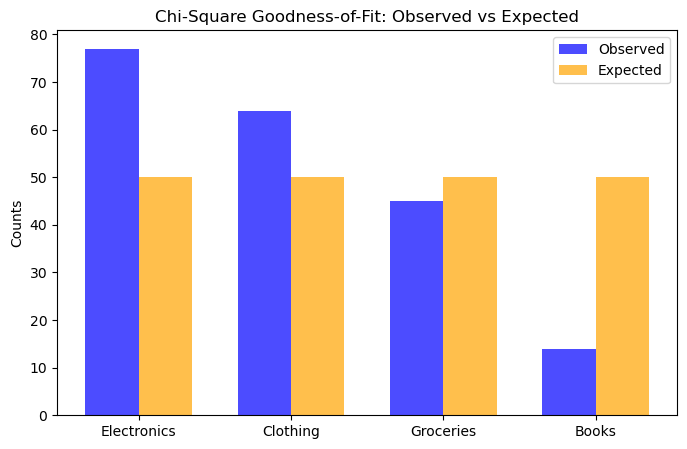

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bar_width = 0.35
x = np.arange(len(categories))

plt.bar(x, df["Observed"], width=bar_width, label="Observed", color="blue", alpha=0.7)
plt.bar(x + bar_width, expected_counts, width=bar_width, label="Expected", color="orange", alpha=0.7)

plt.xticks(x + bar_width/2, categories)
plt.ylabel("Counts")
plt.title("Chi-Square Goodness-of-Fit: Observed vs Expected")
plt.legend()
plt.show()
